## Import the library 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle

## Load data.

In [19]:
data = pd.read_csv("cardio_train.csv", sep=";")
print(f"Initial records: {len(data)}\n")

Initial records: 70000



In [20]:
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


## Duplicate detection.

In [21]:
# Drop id column (not needed for analysis)
data = data.drop('id', axis=1)

# Remove duplicates
before = len(data)
data = data.drop_duplicates()
print(f"Duplicates removed: {before - len(data)}")

Duplicates removed: 24


## Check missing values.

In [22]:
data.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## Handel missing value.

In [23]:
# Define column types
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']

# Handle missing values (if any)
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

## Identify the outliers and handling it.

In [24]:
# Remove outliers (iterative approach)
before = len(data)
for iteration in range(3):  # Run 3 times to catch all outliers
    for col in num_cols:
        Q1, Q3 = data[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        data = data[(data[col] >= Q1 - 1.5*IQR) & (data[col] <= Q3 + 1.5*IQR)]

print(f"Outliers removed: {before - len(data)}")
print(f"Final records: {len(data)}\n")

Outliers removed: 8528
Final records: 61448



## Encode Categorical Variables.

In [25]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')

cat_encoded = encoder.fit_transform(data[cat_cols])
print('Encoded Shape:',cat_encoded.shape)

Encoded Shape: (61448, 14)


## Feature Enginnering

In [26]:
data['bmi'] = data['weight'] / ((data['height']/100) ** 2)  # Body Mass Index
data['pulse_pressure'] = data['ap_hi'] - data['ap_lo']  # Pulse pressure
data['age_years'] = data['age'] / 365  # Convert age to years
data['map'] = (data['ap_hi'] + 2*data['ap_lo']) / 3  # Mean Arterial Pressure

# Add new features to numerical columns list
num_cols_extended = num_cols + ['bmi', 'pulse_pressure', 'age_years', 'map']

## Normalize / Scale Numerical Features.

In [27]:
# Scale numerical features
scaler = StandardScaler()
data[num_cols_extended] = scaler.fit_transform(data[num_cols_extended])

## Exploratory Data Analysis (EDA)

In [28]:
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 61448 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             61448 non-null  float64
 1   gender          61448 non-null  int64  
 2   height          61448 non-null  float64
 3   weight          61448 non-null  float64
 4   ap_hi           61448 non-null  float64
 5   ap_lo           61448 non-null  float64
 6   cholesterol     61448 non-null  int64  
 7   gluc            61448 non-null  int64  
 8   smoke           61448 non-null  int64  
 9   alco            61448 non-null  int64  
 10  active          61448 non-null  int64  
 11  cardio          61448 non-null  int64  
 12  bmi             61448 non-null  float64
 13  pulse_pressure  61448 non-null  float64
 14  age_years       61448 non-null  float64
 15  map             61448 non-null  float64
dtypes: float64(9), int64(7)
memory usage: 8.0 MB
None


In [29]:
print("\nDataset Statistics:")
data.describe()


Dataset Statistics:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse_pressure,age_years,map
count,6.144800e+04,61448.000000,6.144800e+04,6.144800e+04,6.144800e+04,6.144800e+04,61448.000000,61448.000000,61448.000000,61448.000000,61448.000000,61448.000000,6.144800e+04,6.144800e+04,6.144800e+04,6.144800e+04
mean,-7.180820e-17,1.347416,-3.420429e-16,-2.520803e-17,1.868632e-16,-4.447252e-16,1.354772,1.219031,0.086024,0.051735,0.804811,0.491538,4.056412e-16,-1.182927e-16,8.988167e-16,-3.318672e-16
std,1.000008e+00,0.476153,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,0.673107,0.566146,0.280402,0.221493,0.396350,0.499932,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00
min,-2.120701e+00,1.000000,-2.850058e+00,-2.549128e+00,-2.549903e+00,-2.174976e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-2.839836e+00,-5.267673e+00,-2.120701e+00,-2.550986e+00
25%,-7.192010e-01,1.000000,-7.160037e-01,-6.640325e-01,-4.433550e-01,-2.155933e-01,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-7.077789e-01,-4.493992e-01,-7.192010e-01,-3.523307e-01
50%,9.117601e-02,1.000000,8.426663e-02,-1.499156e-01,-4.433550e-01,-2.155933e-01,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-1.839278e-01,-4.493992e-01,9.117601e-02,-3.523307e-01
75%,7.516867e-01,2.000000,7.511586e-01,6.212597e-01,9.610101e-01,1.090662e+00,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,6.150618e-01,5.142556e-01,7.516867e-01,7.469972e-01
max,1.717424e+00,2.000000,2.885213e+00,2.506355e+00,3.067558e+00,3.050045e+00,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,4.803367e+00,5.621626e+00,1.717424e+00,3.238807e+00


Text(0.5, 0.98, 'Distribution of Numerical Features')

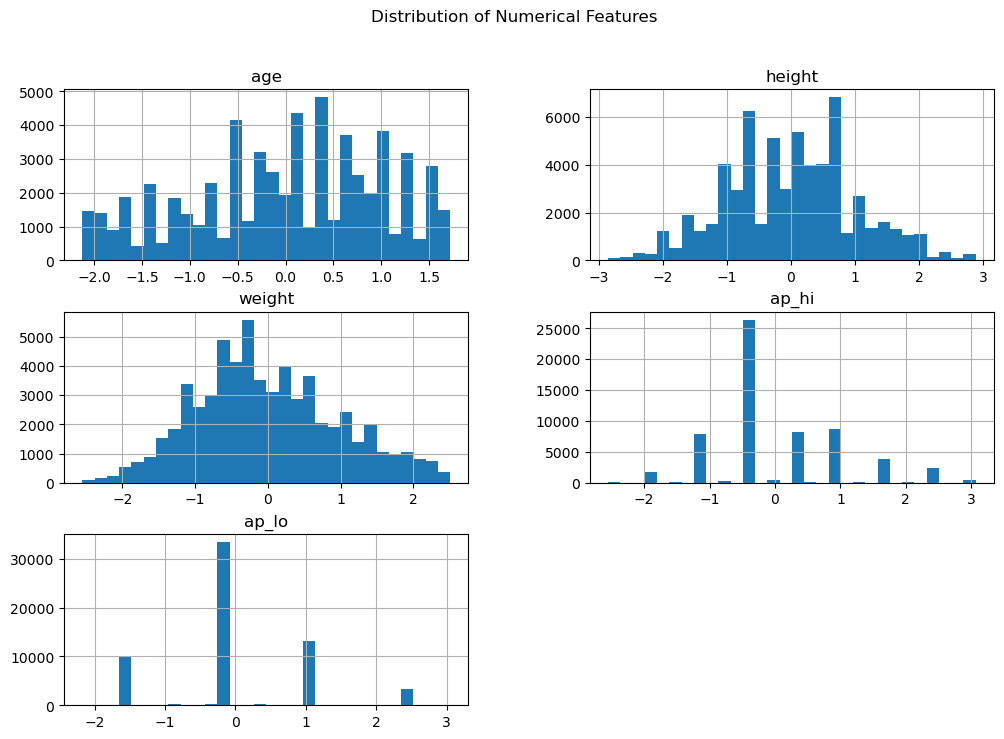

In [30]:
data[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribution of Numerical Features')


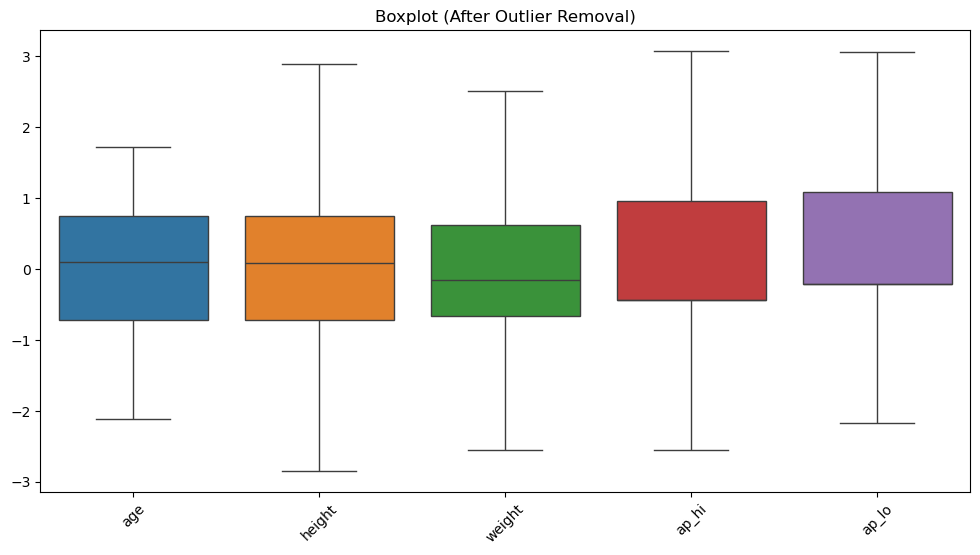

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[num_cols])
plt.title('Boxplot (After Outlier Removal)')
plt.xticks(rotation=45)
plt.show()

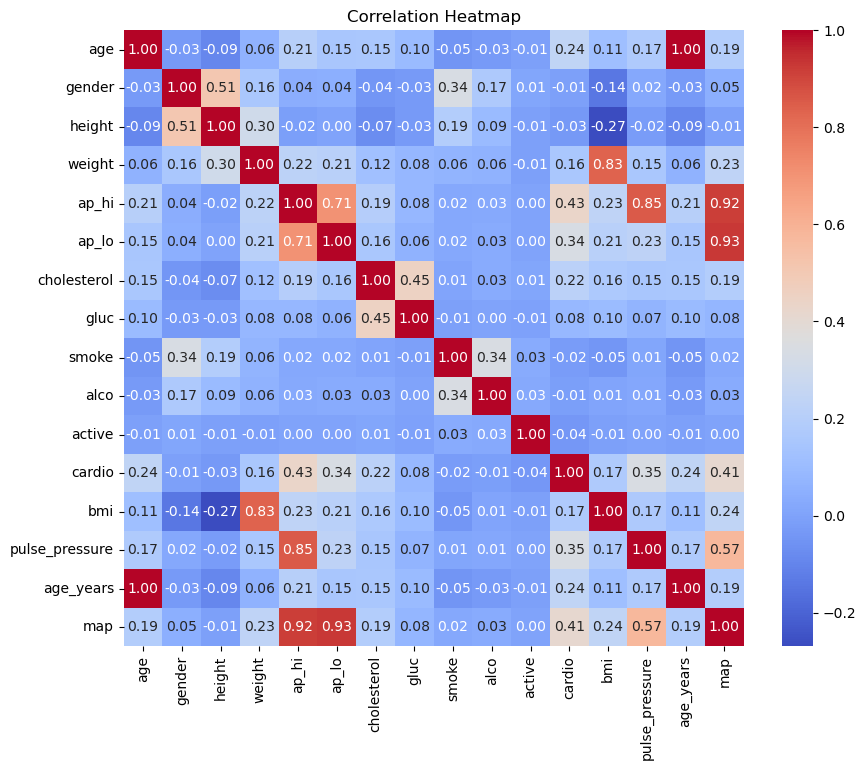

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Target Variable distribution

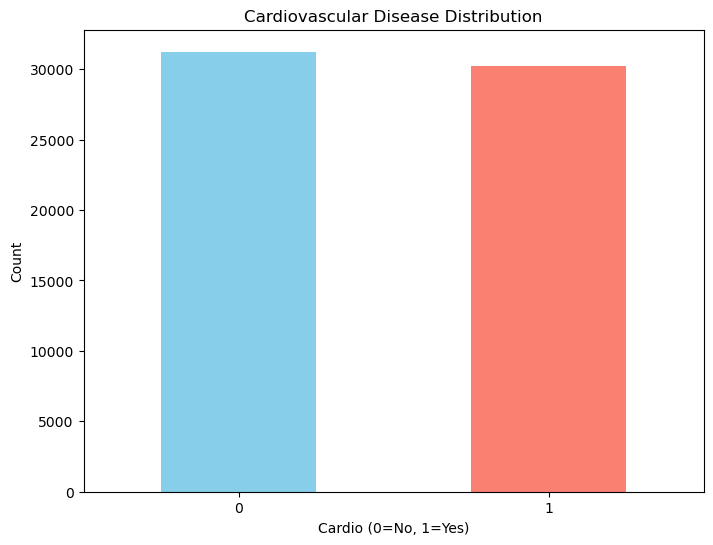

In [32]:
plt.figure(figsize=(8, 6))
data['cardio'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Cardiovascular Disease Distribution')
plt.xlabel('Cardio (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [33]:
data.isnull().sum() 

age               0
gender            0
height            0
weight            0
ap_hi             0
ap_lo             0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio            0
bmi               0
pulse_pressure    0
age_years         0
map               0
dtype: int64

In [34]:
# Save the cleaned dataset
data.to_csv('cleaned_cardio_train.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
